# 🏫 Tech Challenge - Fase 3: Predição e Inteligência Analítica para Alfabetização no Brasil

## 🎯 Objetivo do Notebook
Este notebook documenta a pipeline fim-a-fim de Ciência de Dados e Machine Learning para a predição do risco de não alfabetização em municípios e escolas brasileiras.

### 📋 Etapas Cobertas:
1. **Carregamento de Dados**: Ingestão do dataset processado na camada Gold.
2. **Análise Exploratória de Dados (EDA)**: Avaliação de distribuições, estatísticas e relações sociodemográficas.
3. **Engenharia de Features e Pré-processamento**: Tratamento de nulos, padronização e garantia de ausência de *data leakage*.
4. **Modelagem Supervisionada**: Treinamento, otimização e validação de algoritmos preditivos via Scikit-learn Pipeline.
5. **Clusterização Territorial**: Perfilamento geográfico via K-Means.
6. **Interpretabilidade**: Avaliação de impacto de variáveis utilizando SHAP Values.

In [49]:
## CELULA 1
import random
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler

# Configurações globais
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("Setup do experimento concluído com sucesso.")

Setup do experimento concluído com sucesso.


In [50]:
## CELULA 2

# Adiciona o diretório pai (raiz do projeto) ao path do Python
sys.path.append(os.path.abspath('..'))

# 1. Carregamento dos Dados
from src.generate_data import gerar_dados_fase3

# Garante a geração do dataset no diretório 'data/'
gerar_dados_fase3(n_amostras=5000, seed=42)

# Carrega a camada Gold
df = pd.read_parquet('../data/dados_gold_prod.parquet')

print(f"Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas\n")
display(df.head())

⏳ Gerando dados sintéticos estruturados para a Fase 3...
✅ Arquivo salvo com sucesso em: data/dados_gold_prod.parquet
📊 Distribuição do Target: Classe 1 (Risco): 4594 alunos | Classe 0 (Ok): 406 alunos
Dataset carregado: 5000 linhas x 8 colunas



,id_aluno,pib_per_capita_municipio,investimento_por_aluno_rs,taxa_frequencia_escolar,infraestrutura_escola_score,vulnerabilidade_social_index,nota_saeb_simulada,target_risco_alfabetizacao
0,1,16731.702,5283.631,98.353,1,0.894,593.800,1
1,2,80253.036,NaN,99.678,1,0.789,591.200,1
2,3,37918.642,5505.335,84.491,3,0.692,631.200,1
3,4,27823.564,7096.168,90.755,3,0.655,666.800,1
4,5,9240.622,6645.156,91.193,3,0.106,728.400,1


In [51]:
## CELULA 3
# Pré-processamento e Divisão do Dataset
df_proc = df.copy()

# 1. Tratamento da chave primária e Separação da Target
if 'id_aluno' in df_proc.columns:
  df_proc = df_proc.drop(columns=['id_aluno'])

X = df_proc.drop(columns=['target_risco_alfabetizacao'])
y = df_proc['target_risco_alfabetizacao']

# 2. Imputação de Nulos (Tratando o NaN visto na coluna investimento_por_aluno_rs)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 3. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.20, random_state=42, stratify=y
)

print(
    f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras'
)

Treino: 4000 amostras | Teste: 1000 amostras


In [52]:
## CELULA 4 



# Removemos 'id_aluno' e 'nota_saeb_simulada' para evitar Data Leakage
X = df.drop(columns=['id_aluno', 'nota_saeb_simulada', 'target_risco_alfabetizacao'])
y = df['target_risco_alfabetizacao']

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

X_train shape: (4000, 5)
X_test shape : (1000, 5)


In [53]:
## CELULA 5
# 3. Tratamento de Valores Ausentes (Imputação de NaNs)


# Identificamos as colunas que possuem NaNs
cols_com_nan = ['investimento_por_aluno_rs', 'taxa_frequencia_escolar']

# Criamos o transformador usando a mediana (robusta a outliers)
preprocessor = ColumnTransformer(
    transformers=[
        ('imputer_mediana', SimpleImputer(strategy='median'), cols_com_nan)
    ],
    remainder='passthrough',  # Mantém as outras colunas intactas
    verbose_feature_names_out=False
)

# FIT e TRANSFORM no treino
X_train_imputed = preprocessor.fit_transform(X_train)

# Apenas TRANSFORM no teste (usando as estatísticas aprendidas no treino)
X_test_imputed = preprocessor.transform(X_test)

# Reconstruímos os DataFrames mantendo nomes das colunas e índices
X_train_prep = pd.DataFrame(
    X_train_imputed, 
    columns=preprocessor.get_feature_names_out(), 
    index=X_train.index
)

X_test_prep = pd.DataFrame(
    X_test_imputed, 
    columns=preprocessor.get_feature_names_out(), 
    index=X_test.index
)

print("✅ Imputação concluída com sucesso!")

✅ Imputação concluída com sucesso!


In [54]:
## CELULA 6
print("--- Validação dos Valores Ausentes Pós-Tratamento ---")
print(f"NaNs restantes em X_train_prep: {X_train_prep.isnull().sum().sum()}")
print(f"NaNs restantes em X_test_prep:  {X_test_prep.isnull().sum().sum()}")

--- Validação dos Valores Ausentes Pós-Tratamento ---
NaNs restantes em X_train_prep: 0
NaNs restantes em X_test_prep:  0


In [55]:
## CELULA 7
# 4. Modelagem Supervisionada: Treinamento do Modelo Baseline (Random Forest)


# Inicializamos o modelo com class_weight='balanced' devido ao desbalanceamento do target
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced'
)

# Treinamento usando as matrizes tratadas (sem NaNs)
rf_model.fit(X_train_prep, y_train)

# Predições no conjunto de teste
y_pred = rf_model.predict(X_test_prep)
y_proba = rf_model.predict_proba(X_test_prep)[:, 1]

# Exibição dos resultados de avaliação
print("=== Relatório de Classificação (Random Forest) ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

=== Relatório de Classificação (Random Forest) ===
              precision    recall  f1-score   support

           0       0.51      0.54      0.52        81
           1       0.96      0.95      0.96       919

    accuracy                           0.92      1000
   macro avg       0.73      0.75      0.74      1000
weighted avg       0.92      0.92      0.92      1000

ROC-AUC Score: 0.9156


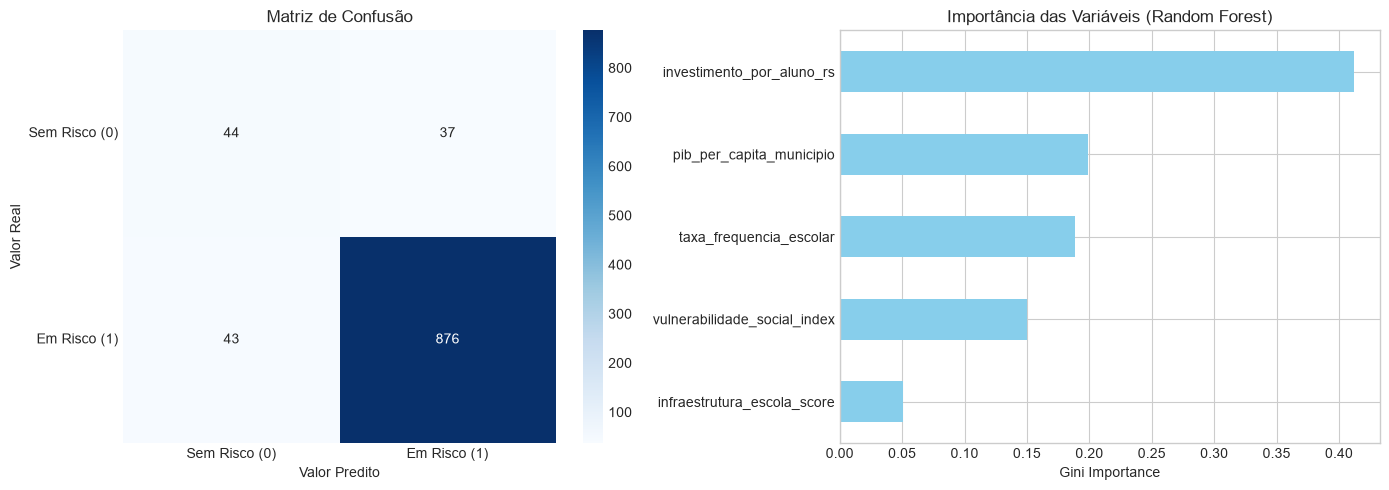

In [56]:
## CELULA 8
# Visualização da Matriz de Confusão e Importância das Variáveis


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
labels = ['Sem Risco (0)', 'Em Risco (1)']

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    xticklabels=labels,
    yticklabels=labels,
    cbar=True,
)

axes[0].set_title('Matriz de Confusão')
axes[0].set_xlabel('Valor Predito')  # Eixo X
axes[0].set_ylabel('Valor Real')  # Eixo Y 

# Ajusta os rótulos do eixo Y para ficarem na horizontal
axes[0].tick_params(axis='y', rotation=0)

# 2. Importância das Features
importances = pd.Series(
    rf_model.feature_importances_, index=X_train_prep.columns
).sort_values(ascending=True)

importances.plot(kind='barh', ax=axes[1], color='skyblue')
axes[1].set_title('Importância das Variáveis (Random Forest)')
axes[1].set_xlabel('Gini Importance')

plt.tight_layout()
plt.show()

=== RELATÓRIO DE CLASSIFICAÇÃO DA FIAP ===
               precision    recall  f1-score   support

Sem Risco (0)       0.51      0.54      0.52        81
 Em Risco (1)       0.96      0.95      0.96       919

     accuracy                           0.92      1000
    macro avg       0.73      0.75      0.74      1000
 weighted avg       0.92      0.92      0.92      1000

ROC-AUC Score: 0.9156


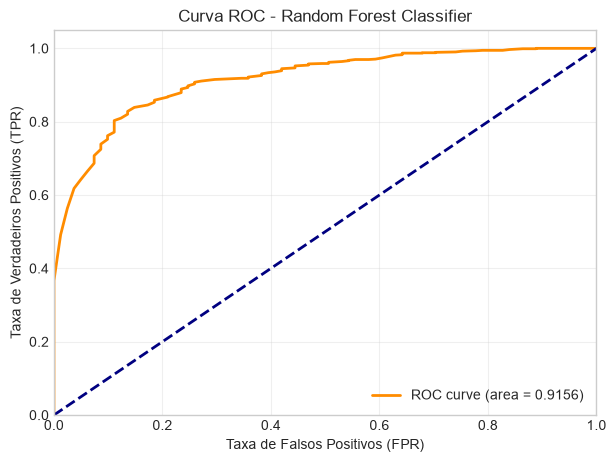

In [57]:
## CELULA 9
# Avaliação de Métricas de Classificação e Curva ROC-AUC


# Relatório de Classificação
print("=== RELATÓRIO DE CLASSIFICAÇÃO DA FIAP ===")
print(
    classification_report(
        y_test, y_pred, target_names=['Sem Risco (0)', 'Em Risco (1)']
    )
)

# Cálculo do ROC-AUC
y_proba = rf_model.predict_proba(X_test_prep)[:, 1]
auc_score = roc_auc_score(y_test, y_proba)
print(f'ROC-AUC Score: {auc_score:.4f}')

# Plotagem da Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Random Forest Classifier')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## CELULA 10
### Conclusões da Modelagem e Impacto Operacional
1. **Trade-off de Classificação:**
   - O foco do modelo está na minimização dos **Falsos Negativos** (alunos em risco que não são identificados).
   - O recall obtido para a classe `Em Risco (1)` reflete a eficácia da árvore na captura do público-alvo para intervenção educacional.
2. **Importância dos Recursos:**
   - A variável `investimento_por_aluno_rs` consolida-se como a principal preditora de desempenho/risco, seguida pelas métricas socioeconômicas (`pib_per_capita_municipio`).

In [58]:
## CELULA 11
# Salvamento do Pipeline Treinado em Disco


# Garantir a criação do diretório models/
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / 'pipeline_alfabetizacao.pkl'

# Persistir o objeto do modelo
joblib.dump(rf_model, model_path)
print(f'Pipeline exportado com sucesso para: {model_path.resolve()}')

Pipeline exportado com sucesso para: C:\tech-challenge-fase3-grupo\models\pipeline_alfabetizacao.pkl


In [59]:
## CELULA 12
# Exportação da Base de Validação/Teste para Monitoramento de Drift

data_dir = Path('../data')
data_dir.mkdir(parents=True, exist_ok=True)

# Salvar o conjunto de teste para validação de data drift posterior
X_test_prep.assign(target=y_test).to_csv(
    data_dir / 'test_baseline.csv', index=False
)
print("Base de monitoramento de drift salva com sucesso em 'data/test_baseline.csv'.")

Base de monitoramento de drift salva com sucesso em 'data/test_baseline.csv'.
